In [1]:
%cd ..

/Users/macos/Uni/1st_year/IntroDS/mini_project


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Read data

In [4]:
path = "res/Oct17_processed_v1.csv"

In [5]:
df = pd.read_csv(path)

df.head()

,country,Year,RP,MP,TP,REI,Prediction
0,Algeria,2012,1.239998,20.000000,1.000000,7.413333,Past
1,Algeria,2013,0.532257,0.999999,1.000000,0.844085,Past
2,Algeria,2014,0.757573,0.989361,1.009105,0.918680,Past
3,Algeria,2015,0.879996,0.956988,1.188309,1.008431,Past
4,Algeria,2016,1.545448,0.179775,1.561241,1.095488,Past


# Visualize

## Lineplot each factor each country

In [147]:
country = "Finland"
col = "MP"

In [148]:
df_country = df[df['country'] == country].set_index('Year')

df_country.head()

,country,RP,MP,TP,REI,Prediction,Continent
Year,,,,,,,
2012,Finland,1.181141,0.115943,0.969708,0.755598,Past,Europe
2013,Finland,0.897409,4.174593,1.025771,2.032591,Past,Europe
2014,Finland,1.025361,0.290020,0.984012,0.766464,Past,Europe
2015,Finland,1.161720,7.397812,1.193037,3.250856,Past,Europe
2016,Finland,0.996069,1.427506,0.638457,1.020677,Past,Europe


/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

Text(0.5, 1.0, 'MP of Finland')

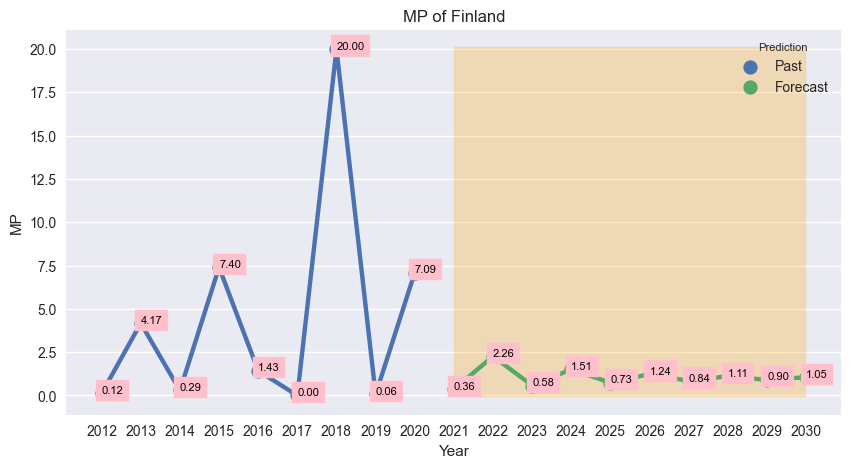

In [149]:
fig = plt.figure(figsize=(10, 5))

ax = fig.add_subplot(111)

sns.pointplot(x=df_country.index, y=df_country[col], hue=df_country['Prediction'], ax=ax)
# sns.barplot(x=df.index, y=df['potential'], hue=df['prediction'], ax=ax, dodge=False)
# plt.legend([], [], frameon=False)

for x, y in zip(ax.get_xticks(), df_country[col]):
    plt.text(x, y, '{:.2f}'.format(y), color='black').set_backgroundcolor('pink')

ax.fill_between(
    ax.get_xticks(),
    df_country[col].min() - 0.1, 
    df_country[col].max() + 0.1, 
    where=ax.get_xticks() >= 9, 
    color='orange',
    alpha=0.25,
)

ax.set_title(f"{col} of {country}")

In [150]:
fig.savefig(f"figs/{col}_{country}.pdf", format="PDF", bbox_inches="tight")

## Lineplot all factors each country

In [151]:
df_tmp = pd.melt(
    df_country.reset_index(), 
    id_vars=['Year', 'country', 'Prediction'],
    value_vars=['RP', 'MP', 'TP', 'REI'],
    value_name='Potential',
    var_name='Factor'
).set_index('Year')

df_tmp.head()

,country,Prediction,Factor,Potential
Year,,,,
2012,Finland,Past,RP,1.181141
2013,Finland,Past,RP,0.897409
2014,Finland,Past,RP,1.025361
2015,Finland,Past,RP,1.161720
2016,Finland,Past,RP,0.996069


/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/macos/miniforge3/envs/introds/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a 

Text(0.5, 1.0, 'All potential factors of Finland')

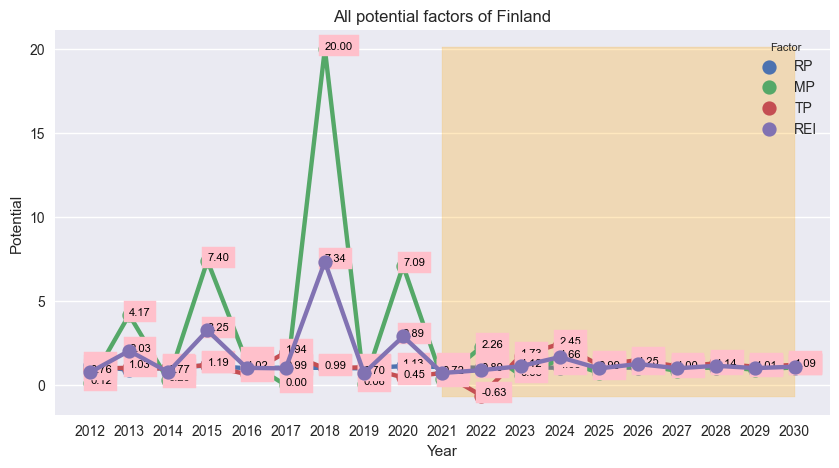

In [152]:
col = 'Potential'

fig = plt.figure(figsize=(10, 5))

ax = fig.add_subplot(111)

sns.pointplot(df_tmp, x=df_tmp.index, y='Potential', hue='Factor', ax=ax)
# sns.barplot(x=df.index, y=df['potential'], hue=df['prediction'], ax=ax, dodge=False)
# plt.legend([], [], frameon=False)
for factor in df_tmp['Factor'].unique():
    df_tmp_ = df_tmp[df_tmp['Factor'] == factor]

    for x, y in zip(ax.get_xticks(), df_tmp_[col]):
        ax.text(x, y, '{:.2f}'.format(y), color='black').set_backgroundcolor('pink')

ax.fill_between(
    ax.get_xticks(),
    df_tmp[col].min() - 0.1, 
    df_tmp[col].max() + 0.1, 
    where=ax.get_xticks() >= 9, 
    color='orange',
    alpha=0.25,
)

ax.set_title(f"All potential factors of {country}")

In [153]:
fig.savefig(f"figs/all_{country}.pdf", format="PDF", bbox_inches="tight")

## Area plot each continent

In [154]:
df.head()

,country,Year,RP,MP,TP,REI,Prediction,Continent
0,Algeria,2012,1.239998,20.000000,1.000000,7.413333,Past,Africa
1,Algeria,2013,0.532257,0.999999,1.000000,0.844085,Past,Africa
2,Algeria,2014,0.757573,0.989361,1.009105,0.918680,Past,Africa
3,Algeria,2015,0.879996,0.956988,1.188309,1.008431,Past,Africa
4,Algeria,2016,1.545448,0.179775,1.561241,1.095488,Past,Africa


In [155]:
df_REI_continent = df.groupby(['Continent', 'Year', 'Prediction'])['REI'].mean().reset_index()
df_REI_continent.head()

,Continent,Year,Prediction,REI
0,Africa,2012,Past,3.283369
1,Africa,2013,Past,2.292523
2,Africa,2014,Past,3.035848
3,Africa,2015,Past,1.786480
4,Africa,2016,Past,3.426536


In [156]:
df_REI_continent_pv = df_REI_continent \
    .pivot(index='Year', columns='Continent', values='REI') \
    .reset_index() \
    .clip(0)
    # .set_index('Year')
    
df_REI_continent_pv.head(20)

Continent,Year,Africa,Antarctica,Asia,Europe,North America,South America
0,2012,3.283369,2.081754,1.118044,2.161088,2.534396,3.058919
1,2013,2.292523,4.521214,1.228361,1.746709,2.402282,2.105994
2,2014,3.035848,1.084117,2.782970,1.603645,2.180977,3.055795
3,2015,1.786480,2.427082,1.585393,3.099790,2.256714,1.562375
4,2016,3.426536,0.695784,1.812642,1.281617,1.639347,3.316910
5,2017,2.436201,3.871352,1.257399,1.199380,2.419365,1.372629
6,2018,2.612736,2.255812,2.341566,2.823894,2.153123,2.658265
7,2019,2.332245,1.407731,2.319133,2.000140,2.550283,1.821591
8,2020,0.603787,0.824693,1.505454,2.375843,1.567871,3.322236
9,2021,0.257436,0.000000,0.907346,0.000000,2.124040,2.275864


In [157]:
df_REI_continent_pv = df_REI_continent_pv.set_index(
    pd.to_datetime(df_REI_continent_pv['Year'], format='%Y')
)

In [158]:
df_REI_continent_pv['REI_Total'] = df_REI_continent_pv['Africa'] +\
    df_REI_continent_pv['Antarctica'] + \
    df_REI_continent_pv['Asia'] + \
    df_REI_continent_pv['Europe'] + \
    df_REI_continent_pv['North America'] + \
    df_REI_continent_pv['South America']

df_REI_continent_pv.head()

Continent,Year,Africa,Antarctica,Asia,Europe,North America,South America,REI_Total
Year,,,,,,,,
2012-01-01,2012,3.283369,2.081754,1.118044,2.161088,2.534396,3.058919,14.237569
2013-01-01,2013,2.292523,4.521214,1.228361,1.746709,2.402282,2.105994,14.297084
2014-01-01,2014,3.035848,1.084117,2.782970,1.603645,2.180977,3.055795,13.743351
2015-01-01,2015,1.786480,2.427082,1.585393,3.099790,2.256714,1.562375,12.717833
2016-01-01,2016,3.426536,0.695784,1.812642,1.281617,1.639347,3.316910,12.172836


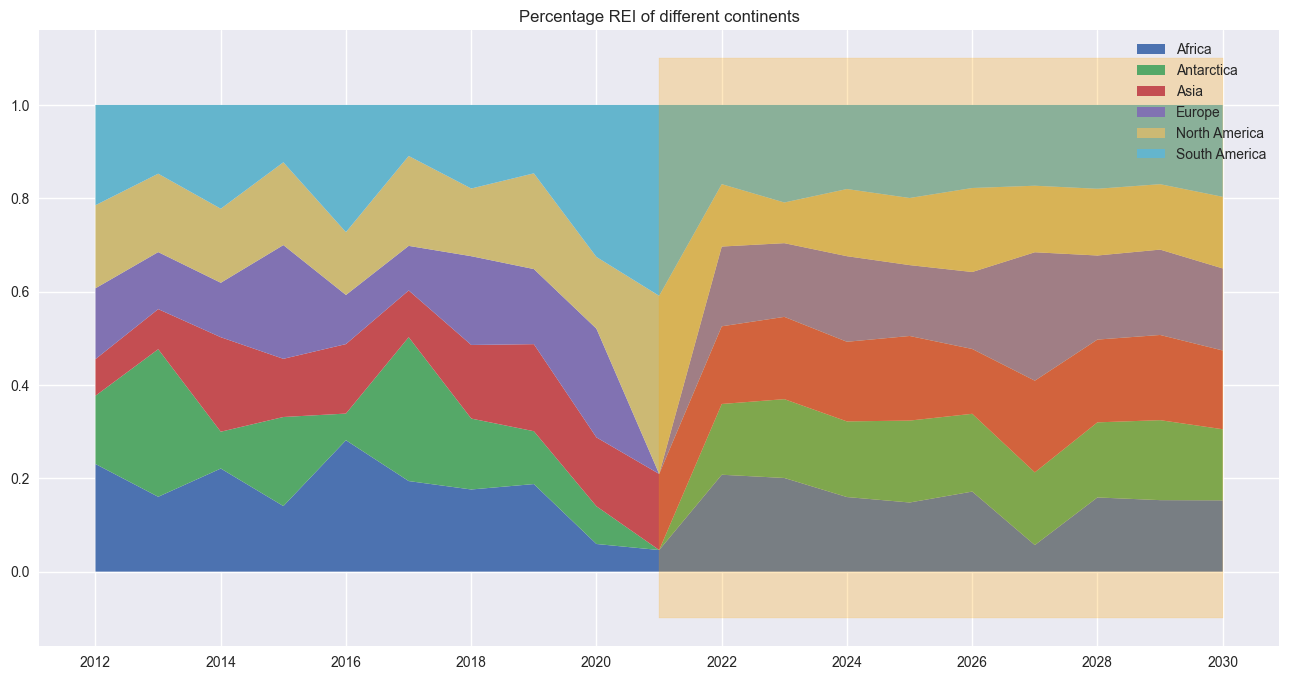

In [159]:
fig = plt.figure(figsize=(16, 8))

ax = fig.add_subplot(111)

ax.stackplot(
    df_REI_continent_pv.index, 
    df_REI_continent_pv['Africa'] / df_REI_continent_pv['REI_Total'], 
    df_REI_continent_pv['Antarctica']  / df_REI_continent_pv['REI_Total'],
    df_REI_continent_pv['Asia']  / df_REI_continent_pv['REI_Total'],
    df_REI_continent_pv['Europe']  / df_REI_continent_pv['REI_Total'],
    df_REI_continent_pv['North America']  / df_REI_continent_pv['REI_Total'],
    df_REI_continent_pv['South America']  / df_REI_continent_pv['REI_Total'],
    labels=['Africa', 'Antarctica', 'Asia', 'Europe', 'North America', 'South America'],
)

ax.legend()
ax.set_title("Percentage REI of different continents")

ax.fill_between(
    df_REI_continent_pv.index,
    -0.1, 
    1.1, 
    where=df_REI_continent_pv.index >= '2021-01-01', 
    color='orange',
    alpha=0.25,
)

In [160]:
fig.savefig("figs/rei_continent_percent.pdf", format="PDF", bbox_inches="tight")

# Heatmap

In [161]:
df_sus = pd.read_csv("res/global-data-on-sustainable-energy.csv")

df_sus.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [171]:
trg = 'Electricity from renewables (TWh)'

trg_corr = df_sus.groupby('Year').mean(trg).corr()[trg]

trg_corr

Access to electricity (% of population)                             0.986600
Access to clean fuels for cooking                                   0.952353
Renewable-electricity-generating-capacity-per-capita                0.991947
Financial flows to developing countries (US $)                      0.546728
Renewable energy share in the total final energy consumption (%)    0.384557
Electricity from fossil fuels (TWh)                                 0.921026
Electricity from nuclear (TWh)                                     -0.493012
Electricity from renewables (TWh)                                   1.000000
Low-carbon electricity (% electricity)                              0.887275
Primary energy consumption per capita (kWh/person)                  0.044459
Energy intensity level of primary energy (MJ/$2017 PPP GDP)        -0.018231
Value_co2_emissions_kt_by_country                                   0.925281
Renewables (% equivalent primary energy)                            0.982204

<Axes: >

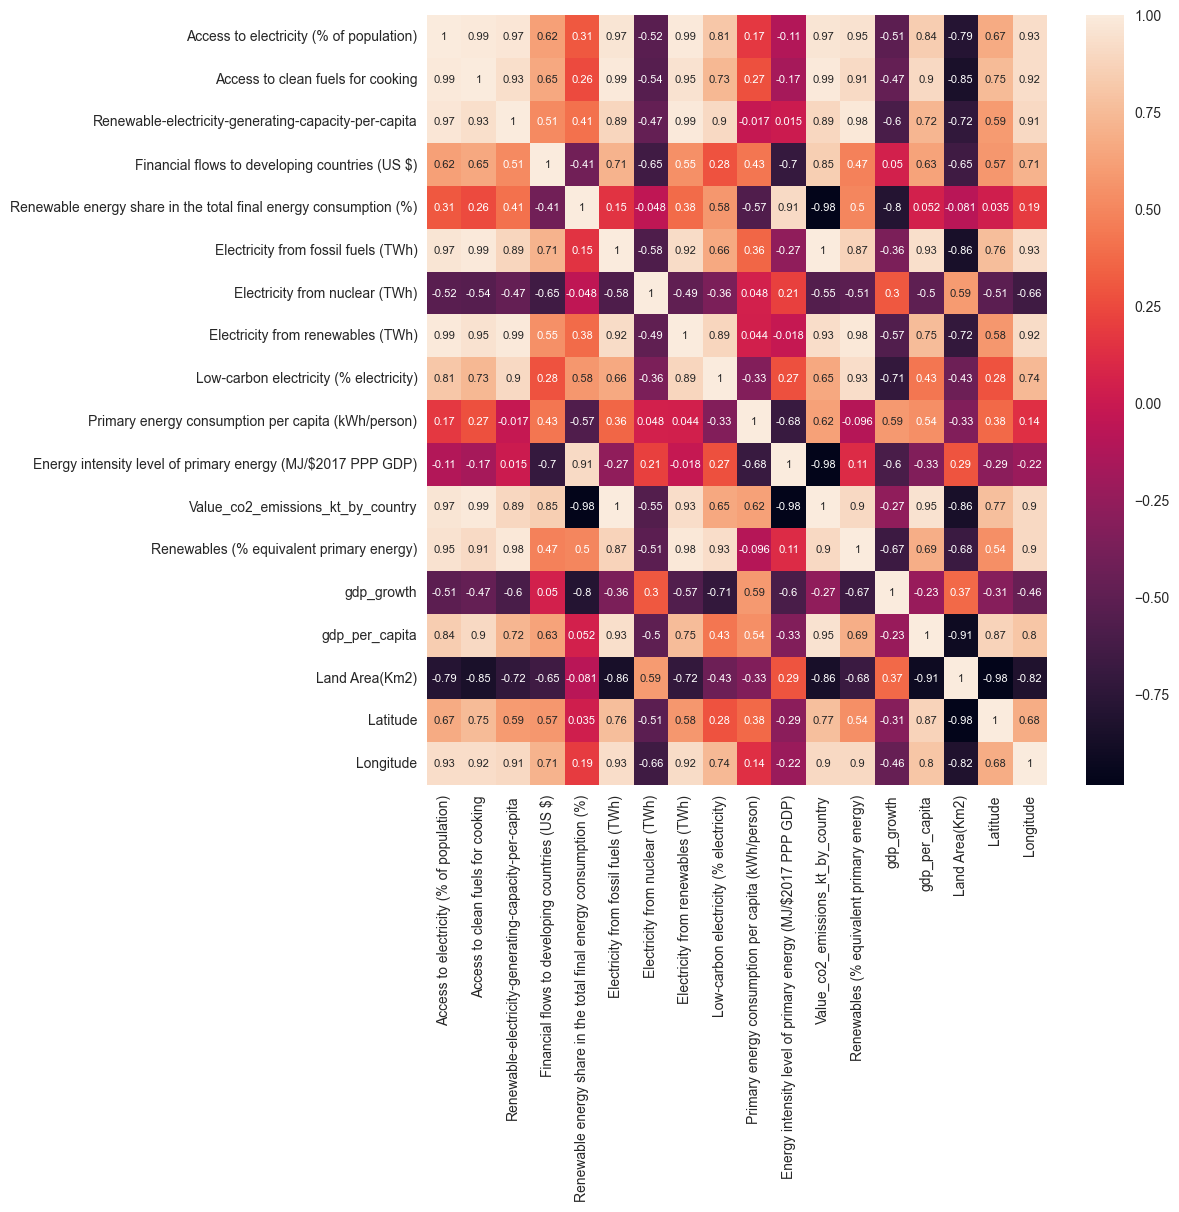

In [174]:
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111)

sns.heatmap(df_sus.groupby('Year').mean(trg).corr(), annot=True, ax=ax)

In [177]:
trg_corr[trg_corr > 0.5]

Access to electricity (% of population)                 0.986600
Access to clean fuels for cooking                       0.952353
Renewable-electricity-generating-capacity-per-capita    0.991947
Financial flows to developing countries (US $)          0.546728
Electricity from fossil fuels (TWh)                     0.921026
Electricity from renewables (TWh)                       1.000000
Low-carbon electricity (% electricity)                  0.887275
Value_co2_emissions_kt_by_country                       0.925281
Renewables (% equivalent primary energy)                0.982204
gdp_per_capita                                          0.754135
Latitude                                                0.578953
Longitude                                               0.919358
Name: Electricity from renewables (TWh), dtype: float64